In [1]:
#Import neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
#Loading the Dataset
data = pd.read_csv('synthetic_text_data.csv')
X = data['text']
y = data['label']

In [4]:
#Split the dataset into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [5]:
#Text Preprocessing: Converting test into numerical features
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [6]:
#Training the model
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

MultinomialNB()

In [7]:
#Making predictions
y_pred = model.predict(X_test_vectorized)

Accuracy:  0.8823529411764706


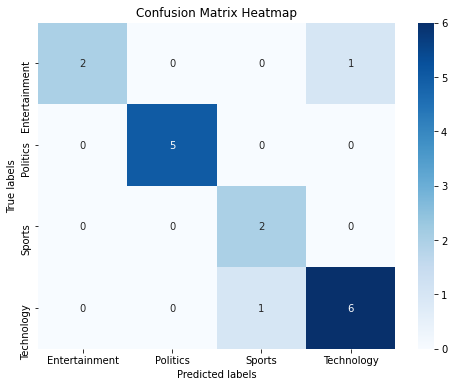

In [10]:
#Evaluating the model
accuracy = accuracy_score(y_pred, y_test)
conf_matrix = confusion_matrix(y_pred, y_test)

print("Accuracy: ", accuracy)

class_labels = np.unique(y_test)

plt.figure(figsize = (8,6))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = class_labels, yticklabels = class_labels)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

In [21]:
#Prediction on Unseen data
user_input = "Majority of Indians work in IT industry"
user_input_vectorized = vectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)
print("The predicted label of the user input is: ", predicted_label[0])

The predicted label of the user input is:  Technology
